# Ewaluacja wytrenowanych modeli

Notebook ładuje pobrane checkpointy z `outputs/checkpoints`, liczy metryki na zbiorze testowym, tworzy raporty per model oraz ewaluuje ensemble trzech najlepszych modeli `CNN+aug` z grid searcha.

Założenia eksperymentu:
- plain `CNN` jest oceniany bez augmentacji i bez TTA,
- `CNN+aug` jest oceniany z `TTA=5`, tak jak w wynikach z klastra,
- ensemble uśrednia predykcje trzech pełnych modeli wieloklasowych, a nie one-vs-rest.

In [1]:
from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from room_classifier.data import load_or_create_split, split_summary
from room_classifier.evaluate import evaluate_checkpoint, evaluate_ensemble, plot_confusion_matrix
from room_classifier.train_utils import get_device

DATA_DIR = (ROOT.parent / 'data' / 'raw' / 'kaggle_room_street_data' / 'house_data').resolve()
SPLIT_CSV = ROOT / 'splits' / 'room_split_seed42_local_eval.csv'
CHECKPOINT_DIR = ROOT / 'outputs' / 'checkpoints'
REPORT_DIR = ROOT / 'outputs' / 'reports' / 'notebook_final_eval'
SUMMARY_PATH = REPORT_DIR / 'summary_test.csv'

BATCH_SIZE = 16
NUM_WORKERS = 0
DEVICE = 'auto'
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('REPORT_DIR:', REPORT_DIR)
print('DEVICE:', get_device(DEVICE))

ROOT: /Users/andywhy/Projects/dl_aga/python_training
DATA_DIR: /Users/andywhy/Projects/dl_aga/data/raw/kaggle_room_street_data/house_data
CHECKPOINT_DIR: /Users/andywhy/Projects/dl_aga/python_training/outputs/checkpoints
REPORT_DIR: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval
DEVICE: mps


In [2]:
split_frame = load_or_create_split(
    DATA_DIR,
    SPLIT_CSV,
    exclude_classes=['bath'],
    seed=SEED,
)
split_summary(split_frame)

label,bed,din,kitchen,living
split,,,,
train,873,811,675,891
val,187,174,145,191
test,188,173,145,191


In [3]:
MODEL_CONFIGS = [
    {
        'name': 'mlp_best_grid_96',
        'family': 'MLP',
        'path': CHECKPOINT_DIR / 'grid_mlp_96_lr5e4_wd1e4_d50' / 'mlp_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'cnn_best_plain_large_224',
        'family': 'CNN bez augmentacji',
        'path': CHECKPOINT_DIR / 'grid_cnn_large_lr3e4_wd1e3_d50' / 'cnn_best.pt',
        'tta_passes': 1,
    },
    {
        'name': 'cnn_aug_rank1_large_256',
        'family': 'CNN+aug',
        'path': CHECKPOINT_DIR / 'hgrid_aug_large_256_lr2e4_wd5e4_d40_m45_cos_ema' / 'cnn_aug_best.pt',
        'tta_passes': 5,
    },
    {
        'name': 'cnn_aug_rank2_large_256',
        'family': 'CNN+aug',
        'path': CHECKPOINT_DIR / 'hgrid_aug_large_256_lr3e4_wd5e4_d40_m30_cos_ema' / 'cnn_aug_best.pt',
        'tta_passes': 5,
    },
    {
        'name': 'cnn_aug_rank3_large_256',
        'family': 'CNN+aug',
        'path': CHECKPOINT_DIR / 'hgrid_aug_large_256_lr2e4_wd5e4_d45_m45_cos_ema' / 'cnn_aug_best.pt',
        'tta_passes': 5,
    },
]

ENSEMBLES = [
    {
        'name': 'ensemble_top3_cnn_aug_tta5',
        'family': 'Ensemble CNN+aug',
        'paths': [config['path'] for config in MODEL_CONFIGS if config['family'] == 'CNN+aug'],
        'tta_passes': 5,
    }
]

missing = [str(config['path']) for config in MODEL_CONFIGS if not config['path'].is_file()]
for ensemble in ENSEMBLES:
    missing.extend(str(path) for path in ensemble['paths'] if not path.is_file())

if missing:
    raise FileNotFoundError('Brakuje checkpointów:\n' + '\n'.join(missing))

pd.DataFrame([
    {
        'name': config['name'],
        'family': config['family'],
        'checkpoint': str(config['path'].relative_to(ROOT)),
        'tta_passes': config['tta_passes'],
    }
    for config in MODEL_CONFIGS
])

,name,family,checkpoint,tta_passes
0,mlp_best_grid_96,MLP,outputs/checkpoints/grid_mlp_96_lr5e4_wd1e4_d5...,1
1,cnn_best_plain_large_224,CNN bez augmentacji,outputs/checkpoints/grid_cnn_large_lr3e4_wd1e3...,1
2,cnn_aug_rank1_large_256,CNN+aug,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...,5
3,cnn_aug_rank2_large_256,CNN+aug,outputs/checkpoints/hgrid_aug_large_256_lr3e4_...,5
4,cnn_aug_rank3_large_256,CNN+aug,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...,5


Evaluating mlp_best_grid_96 (MLP), TTA=1


predict:   0%|          | 0/44 [00:00<?, ?it/s]

Evaluating cnn_best_plain_large_224 (CNN bez augmentacji), TTA=1


predict:   0%|          | 0/44 [00:00<?, ?it/s]

Evaluating cnn_aug_rank1_large_256 (CNN+aug), TTA=5


...

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

,name,family,model_type,arch,split,accuracy,macro_f1,tta_passes,checkpoint
2,cnn_aug_rank1_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.888092,0.886980,5,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...
3,cnn_aug_rank2_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.888092,0.886434,5,outputs/checkpoints/hgrid_aug_large_256_lr3e4_...
4,cnn_aug_rank3_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.882353,0.880602,5,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...
1,cnn_best_plain_large_224,CNN bez augmentacji,cnn,room_resnet_large,test,0.649928,0.652312,1,outputs/checkpoints/grid_cnn_large_lr3e4_wd1e3...
0,mlp_best_grid_96,MLP,mlp,mlp_1024_512_256,test,0.408895,0.407953,1,outputs/checkpoints/grid_mlp_96_lr5e4_wd1e4_d5...


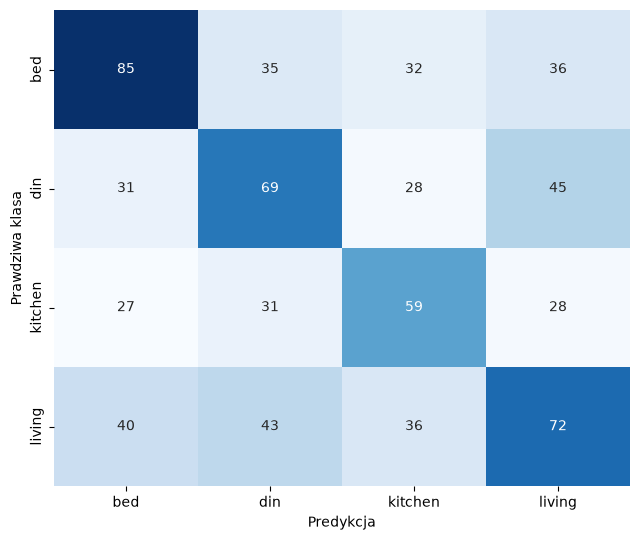

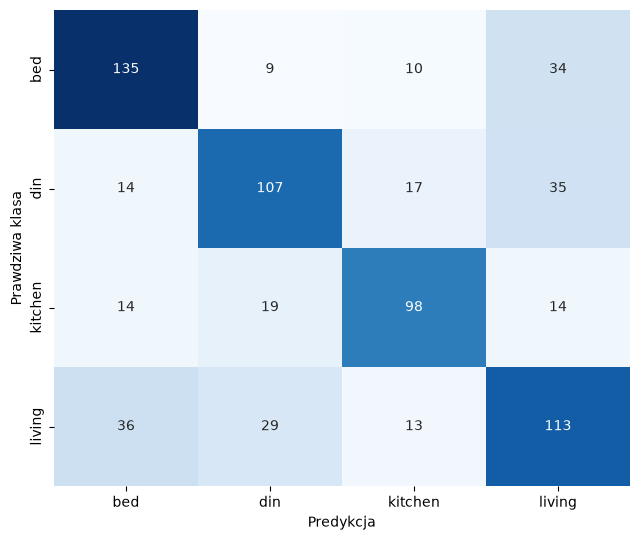

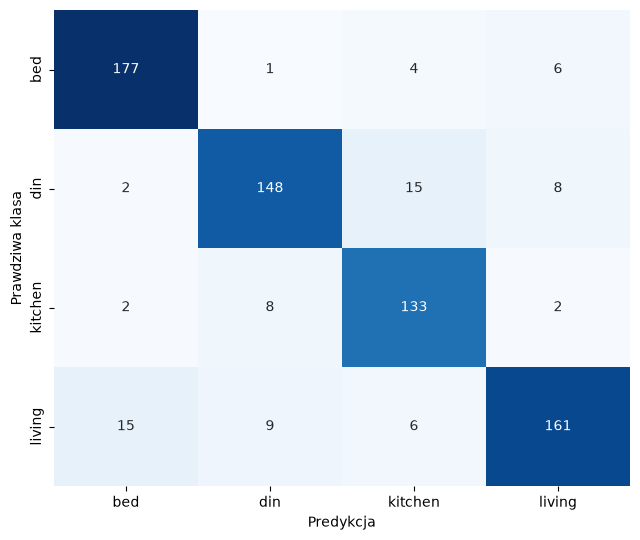

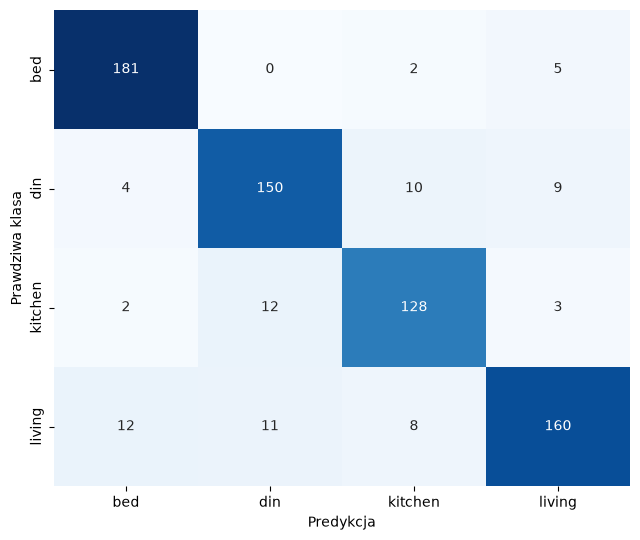

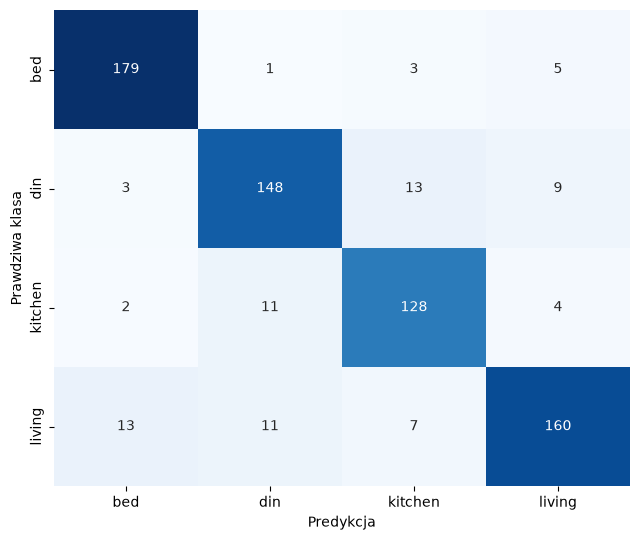

In [4]:
individual_results = []

for config in MODEL_CONFIGS:
    print(f"Evaluating {config['name']} ({config['family']}), TTA={config['tta_passes']}")
    metrics = evaluate_checkpoint(
        checkpoint_path=config['path'],
        data_dir=DATA_DIR,
        split_csv=SPLIT_CSV,
        split='test',
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        device_name=DEVICE,
        output_dir=REPORT_DIR / config['name'],
        tta_passes=config['tta_passes'],
        hard_examples=80,
    )
    metrics['name'] = config['name']
    metrics['family'] = config['family']
    individual_results.append(metrics)

individual_summary = pd.DataFrame([
    {
        'name': metrics['name'],
        'family': metrics['family'],
        'model_type': metrics['model_type'],
        'arch': metrics['arch'],
        'split': metrics['split'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'tta_passes': metrics['tta_passes'],
        'checkpoint': str(Path(metrics['checkpoint']).relative_to(ROOT)),
    }
    for metrics in individual_results
]).sort_values(['macro_f1', 'accuracy'], ascending=False)

individual_summary

Evaluating ensemble_top3_cnn_aug_tta5, models=3, TTA=5


predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

...

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

predict:   0%|          | 0/44 [00:00<?, ?it/s]

,name,family,model_type,arch,split,accuracy,macro_f1,tta_passes,checkpoint
0,ensemble_top3_cnn_aug_tta5,Ensemble CNN+aug,ensemble,cnn_aug:room_resnet_large+cnn_aug:room_resnet_...,test,0.898135,0.897019,5,hgrid_aug_large_256_lr2e4_wd5e4_d40_m45_cos_em...


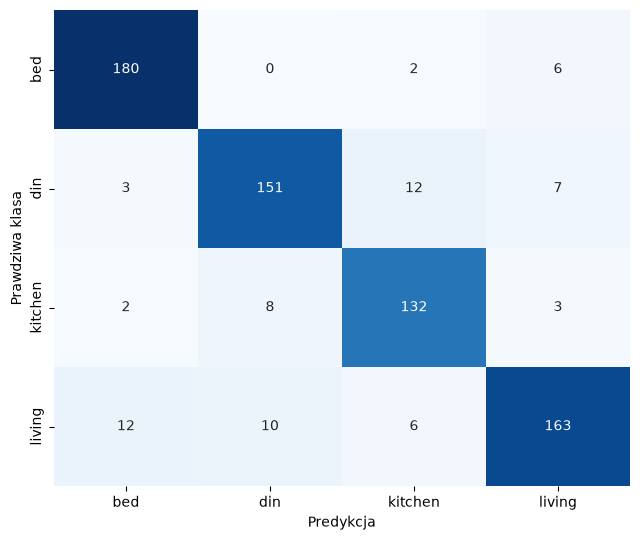

In [5]:
ensemble_results = []

for config in ENSEMBLES:
    print(f"Evaluating {config['name']}, models={len(config['paths'])}, TTA={config['tta_passes']}")
    metrics = evaluate_ensemble(
        checkpoint_paths=config['paths'],
        data_dir=DATA_DIR,
        split_csv=SPLIT_CSV,
        split='test',
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        device_name=DEVICE,
        output_dir=REPORT_DIR / config['name'],
        tta_passes=config['tta_passes'],
        hard_examples=120,
        name=config['name'],
    )
    metrics['name'] = config['name']
    metrics['family'] = config['family']
    ensemble_results.append(metrics)

ensemble_summary = pd.DataFrame([
    {
        'name': metrics['name'],
        'family': metrics['family'],
        'model_type': metrics['model_type'],
        'arch': metrics['arch'],
        'split': metrics['split'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'tta_passes': metrics['tta_passes'],
        'checkpoint': ' + '.join(Path(path).parent.name for path in ENSEMBLES[0]['paths']),
    }
    for metrics in ensemble_results
]).sort_values(['macro_f1', 'accuracy'], ascending=False)

ensemble_summary

In [6]:
summary = pd.concat([individual_summary, ensemble_summary], ignore_index=True)
summary = summary.sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
summary.to_csv(SUMMARY_PATH, index=False)
summary

,name,family,model_type,arch,split,accuracy,macro_f1,tta_passes,checkpoint
0,ensemble_top3_cnn_aug_tta5,Ensemble CNN+aug,ensemble,cnn_aug:room_resnet_large+cnn_aug:room_resnet_...,test,0.898135,0.897019,5,hgrid_aug_large_256_lr2e4_wd5e4_d40_m45_cos_em...
1,cnn_aug_rank1_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.888092,0.886980,5,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...
2,cnn_aug_rank2_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.888092,0.886434,5,outputs/checkpoints/hgrid_aug_large_256_lr3e4_...
3,cnn_aug_rank3_large_256,CNN+aug,cnn_aug,room_resnet_large,test,0.882353,0.880602,5,outputs/checkpoints/hgrid_aug_large_256_lr2e4_...
4,cnn_best_plain_large_224,CNN bez augmentacji,cnn,room_resnet_large,test,0.649928,0.652312,1,outputs/checkpoints/grid_cnn_large_lr3e4_wd1e3...
5,mlp_best_grid_96,MLP,mlp,mlp_1024_512_256,test,0.408895,0.407953,1,outputs/checkpoints/grid_mlp_96_lr5e4_wd1e4_d5...


In [7]:
best_metrics = sorted(
    individual_results + ensemble_results,
    key=lambda metrics: (metrics['macro_f1'], metrics['accuracy']),
    reverse=True,
)[0]

print('Best model:', best_metrics['name'])
print('Accuracy:', round(best_metrics['accuracy'], 4))
print('Macro F1:', round(best_metrics['macro_f1'], 4))

pd.DataFrame(best_metrics['classification_report']).T.round(3)

Best model: ensemble_top3_cnn_aug_tta5
Accuracy: 0.8981
Macro F1: 0.897


,precision,recall,f1-score,support
bed,0.914,0.957,0.935,188.000
din,0.893,0.873,0.883,173.000
kitchen,0.868,0.910,0.889,145.000
living,0.911,0.853,0.881,191.000
accuracy,0.898,0.898,0.898,0.898
macro avg,0.897,0.899,0.897,697.000
weighted avg,0.898,0.898,0.898,697.000


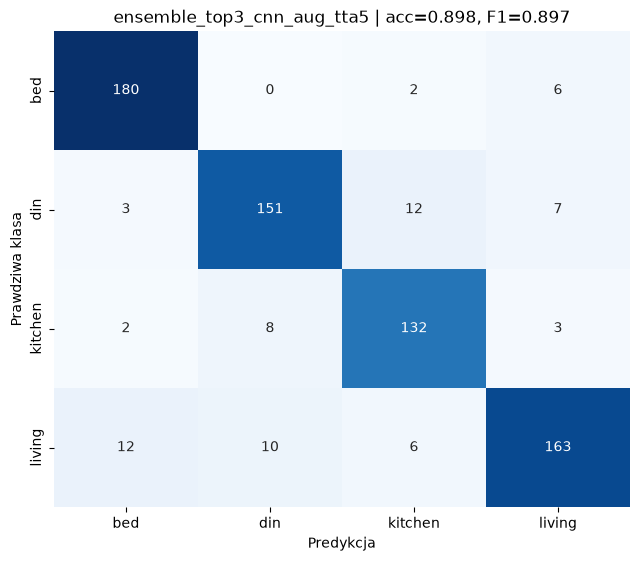

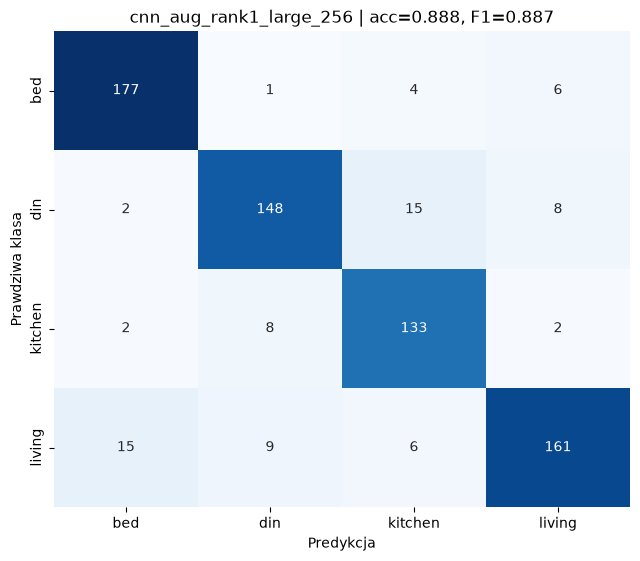

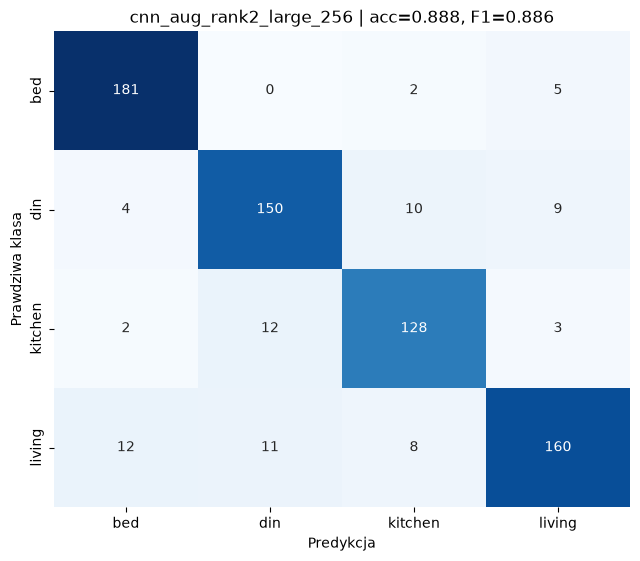

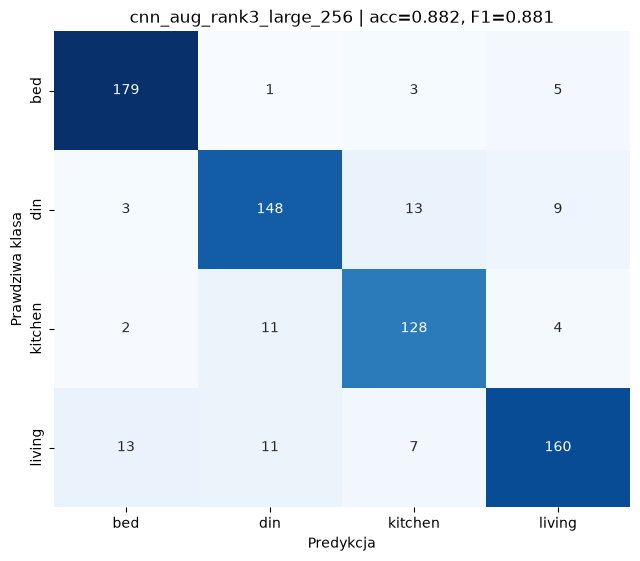

In [8]:
for metrics in sorted(individual_results + ensemble_results, key=lambda item: item['macro_f1'], reverse=True)[:4]:
    fig, ax = plot_confusion_matrix(metrics['confusion_matrix'], metrics['class_names'])
    ax.set_title(f"{metrics['name']} | acc={metrics['accuracy']:.3f}, F1={metrics['macro_f1']:.3f}")
    plt.show()

In [9]:
hard_examples_path = REPORT_DIR / best_metrics['name'] / f"{best_metrics['name']}.test.hard_examples.csv"
if not hard_examples_path.exists():
    hard_examples_path = next((REPORT_DIR / best_metrics['name']).glob('*.hard_examples.csv'))

hard_examples = pd.read_csv(hard_examples_path)
hard_examples.head(20)

,path,label,true_idx,pred_idx,pred_label,pred_confidence,true_probability,confidence_margin,is_correct
0,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.916102,0.032807,0.883295,False
1,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,living,3,2,kitchen,0.911840,0.018956,0.862467,False
2,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,bed,0,2,kitchen,0.908832,0.028537,0.873180,False
3,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.889300,0.042492,0.846808,False
4,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,bed,0,2,kitchen,0.883377,0.039476,0.843901,False
5,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,kitchen,2,1,din,0.865699,0.066821,0.798878,False
6,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,3,living,0.865525,0.047445,0.818080,False
7,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,2,kitchen,0.861416,0.079449,0.781967,False
8,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,living,3,0,bed,0.856523,0.077604,0.778920,False
9,/Users/andywhy/Projects/dl_aga/data/raw/kaggle...,din,1,3,living,0.854273,0.046324,0.797653,False


In [10]:
print('Saved summary:', SUMMARY_PATH)
print('Saved per-model reports under:', REPORT_DIR)

Saved summary: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval/summary_test.csv
Saved per-model reports under: /Users/andywhy/Projects/dl_aga/python_training/outputs/reports/notebook_final_eval
